In [8]:
import time
import math
import numpy as np
from numpy.linalg import norm
import pinocchio as pin
import example_robot_data as robex

from scipy.optimize import fmin_bfgs
from scipy import interpolate
from matplotlib import pyplot as plt
from pinocchio.visualize import MeshcatVisualizer
import meshcat

In [21]:
# Visualization
robot = robex.load('ur5')

# vizualizer = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
# vizualizer.initViewer(loadModel=True, viewer=meshcat.Visualizer())

# Viewer Wrapper
from meshcat_viewer_wrapper import MeshcatVisualizer, colors
viz = MeshcatVisualizer(robot)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7014/static/


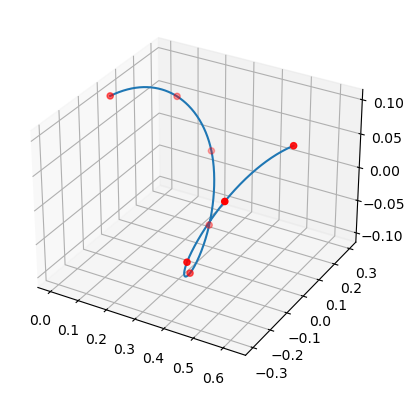

In [48]:
# Spline gen
x_range = 2*np.pi
x = np.linspace(0, x_range, 8)
y = np.array([x, 3*np.sin(x), np.cos(x)])*0.1
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, x_range, 500)
bspl = interpolate.make_interp_spline(x, y, k=3, bc_type=None, axis=1)
ax.plot3D(*bspl(xx))
ax.scatter3D(*y, color='red')
plt.show()

# plt.plot(bspl(xx)[0], bspl(xx)[1], label="B-spline")

In [57]:
# 3D traj follow
def get_target_cfg(target, last_q=None):

    def cost(q):
        '''Compute score from a configuration'''
        m = robot.framePlacement(q, 22)
        p = m.translation
        # offset = m.rotation[:, 2] * radius
        # return norm(p +  offset - target)**2
        return norm(p - target)**2

    if last_q is None:
        last_q = robot.q0
    return fmin_bfgs(cost, last_q, disp=False)

def vis_target_reach(target, last_q=None):
    ball_position = list(target)
    ball_rad = 0.07
    ball_id = 'world/ball'
    viz.addSphere(ball_id, ball_rad, colors.red)
    q_ball = ball_position +  [1, 0, 0, 0]
    viz.applyConfiguration(ball_id, q_ball)
    cfg = get_target_cfg(target, last_q)
    viz.display(cfg)
    return cfg

last_q = None
for pos in xx:
    last_q = vis_target_reach(bspl(pos), last_q) # is more smooth than without last_q
    # last_q = vis_target_reach(bspl(pos))
    # time.sleep(0.004)
